---
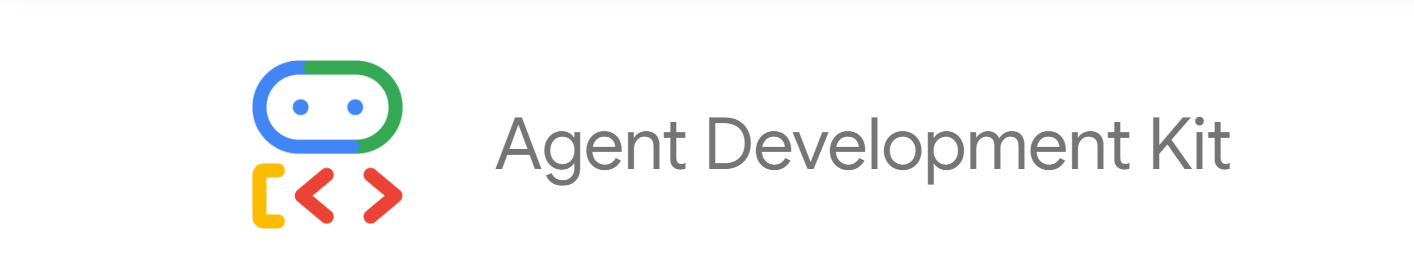

---

# Logging in the **Agent Development Kit** (`ADK`)
The Agent Development Kit (ADK) uses Python's standard `logging` module to provide flexible and powerful logging capabilities. Understanding how to configure and interpret these logs is crucial for monitoring agent behavior and debugging issues effectively.

## Logging Philosophy
ADK's approach to logging is to provide detailed diagnostic information without being overly verbose by default. It is designed to be configured by the application developer, allowing you to tailor the log output to your specific needs, whether in a development or production environment. <br>
- **Standard Library:** It uses the standard logging library, so any configuration or handler that works with it will work with ADK.

- **Hierarchical Loggers:** Loggers are named hierarchically based on the module path (e.g., `google_adk.google.adk.agents.llm_agent`), allowing for fine-grained control over which parts of the framework produce logs.

- **User-Configured:** The framework does not configure logging itself. It is the responsibility of the developer using the framework to set up the desired logging configuration in their application's entry point.

## How to Configure Logging
You can configure logging in your main application script (e.g., `main.py`) before you initialize and run your agent. The simplest way is to use `logging.basicConfig`.

### `Example Configuration`
To enable detailed logging, including `DEBUG` level messages, add the following to the top of your script:

```Python
import logging

logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)

# Your ADK agent code follows...
# from google.adk.agents import LlmAgent
# ...
```

---

## Configuring Logging with the ADK CLI
When running agents using the ADK's built-in web or API servers, you can easily control the log verbosity directly from the command line. The `adk web`, `adk api_server`, and `adk deploy cloud_run` commands all accept a `--log_level` option.

This provides a convenient way to set the logging level without modifying your agent's source code.

> **Note:** The command-line setting always takes precedence over the programmatic configuration (like `logging.basicConfig`) for ADK's loggers. It's recommended to use `INFO` or `WARNING` in production and enable `DEBUG` only when troubleshooting.

### **Example using** `adk web`
To start the web server with `DEBUG` level logging, run:
```Python
adk web --log_level DEBUG path/to/your/agents_dir
```

The available log levels for the `--log_level` option are:
- `DEBUG`

- `INFO (default)`

- `WARNING`

- `ERROR`

- `CRITICAL`

<br>

> You can also use -v or --verbose as a a shortcut for --log_level DEBUG.

```Python
adk web -v path/to/your/agents_dir
```


----

## Log Levels
ADK uses standard log levels to categorize messages. The configured level determines what information gets logged.

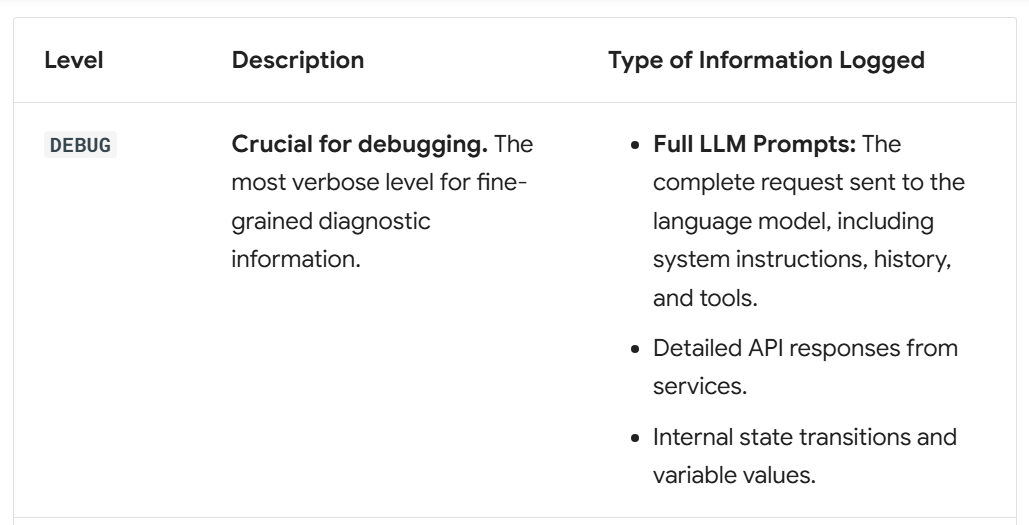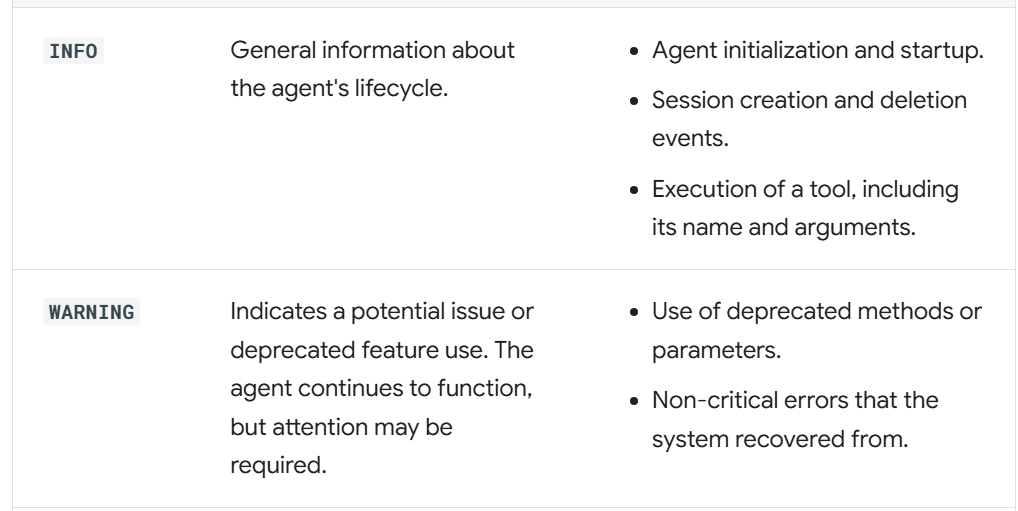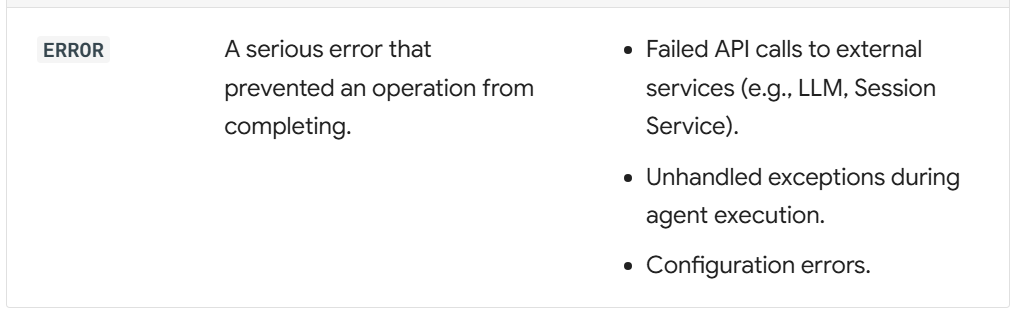 <br><br>

> **Note:** It is recommended to use `INFO` or `WARNING` in production environments. Only enable `DEBUG` when actively troubleshooting an issue, as `DEBUG` logs can be very verbose and may contain sensitive information.

---

## Reading and Understanding the Logs
The `format` string in the `basicConfig` example determines the structure of each log message. <br>

Here’s a sample log entry:

```Python
2025-07-08 11:22:33,456 - DEBUG - google_adk.google.adk.models.google_llm - LLM Request: contents { ... }
```

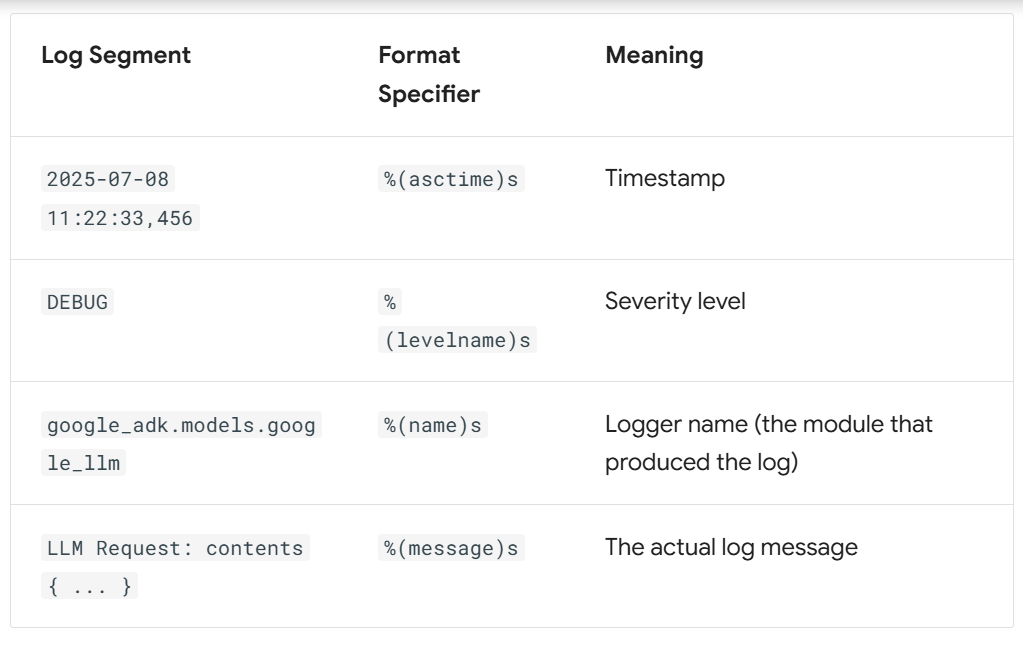

> By reading the logger name, you can immediately pinpoint the source of the log and understand its context within the agent's architecture.

---


## **Debugging with Logs:** A Practical Example
**Scenario:** Your agent is not producing the expected output, and you suspect the prompt being sent to the LLM is incorrect or missing information. <br>

**Steps:** <br>

**1. Enable DEBUG Logging:** In your main.py, set the logging level to `DEBUG` as shown in the configuration example.

```Python
logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)
```

**2. Run Your Agent:** Execute your agent's task as you normally would.

**3. Inspect the Logs:** Look through the console output for a message from the `google.adk.models.google_llm` logger that starts with LLM Request:

```Python
...
2025-07-10 15:26:13,778 - DEBUG - google_adk.google.adk.models.google_llm - Sending out request, model: gemini-2.0-flash, backend: GoogleLLMVariant.GEMINI_API, stream: False
2025-07-10 15:26:13,778 - DEBUG - google_adk.google.adk.models.google_llm - 
LLM Request:
-----------------------------------------------------------
System Instruction:

      You roll dice and answer questions about the outcome of the dice rolls.
      You can roll dice of different sizes.
      You can use multiple tools in parallel by calling functions in parallel(in one request and in one round).
      It is ok to discuss previous dice roles, and comment on the dice rolls.
      When you are asked to roll a die, you must call the roll_die tool with the number of sides. Be sure to pass in an integer. Do not pass in a string.
      You should never roll a die on your own.
      When checking prime numbers, call the check_prime tool with a list of integers. Be sure to pass in a list of integers. You should never pass in a string.
      You should not check prime numbers before calling the tool.
      When you are asked to roll a die and check prime numbers, you should always make the following two function calls:
      1. You should first call the roll_die tool to get a roll. Wait for the function response before calling the check_prime tool.
      2. After you get the function response from roll_die tool, you should call the check_prime tool with the roll_die result.
        2.1 If user asks you to check primes based on previous rolls, make sure you include the previous rolls in the list.
      3. When you respond, you must include the roll_die result from step 1.
      You should always perform the previous 3 steps when asking for a roll and checking prime numbers.
      You should not rely on the previous history on prime results.


You are an agent. Your internal name is "hello_world_agent".

The description about you is "hello world agent that can roll a dice of 8 sides and check prime numbers."
-----------------------------------------------------------
Contents:
{"parts":[{"text":"Roll a 6 sided dice"}],"role":"user"}
{"parts":[{"function_call":{"args":{"sides":6},"name":"roll_die"}}],"role":"model"}
{"parts":[{"function_response":{"name":"roll_die","response":{"result":2}}}],"role":"user"}
-----------------------------------------------------------
Functions:
roll_die: {'sides': {'type': <Type.INTEGER: 'INTEGER'>}} 
check_prime: {'nums': {'items': {'type': <Type.INTEGER: 'INTEGER'>}, 'type': <Type.ARRAY: 'ARRAY'>}} 
-----------------------------------------------------------

2025-07-10 15:26:13,779 - INFO - google_genai.models - AFC is enabled with max remote calls: 10.
2025-07-10 15:26:14,309 - INFO - google_adk.google.adk.models.google_llm - 
LLM Response:
-----------------------------------------------------------
Text:
I have rolled a 6 sided die, and the result is 2.
...
```

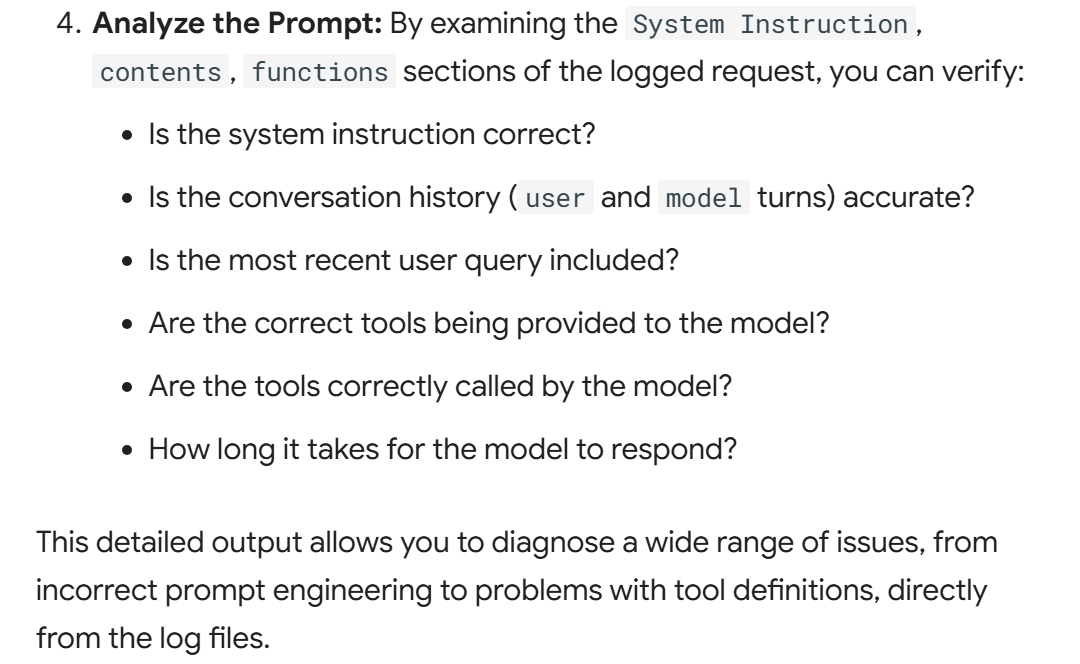


----